# Dataset Analysis

In this notebook we make general analysis of the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from workspace.sources.local_datasets.dataset import Dataset
from workspace.sources.local_datasets.preprocessing.tokenization import NLTKTokenizer, BERTTokenizer, GPT1_Tokenizer
from workspace.sources.local_datasets.preprocessing.pipelines import PreprocessingPipeline
from workspace.sources.local_datasets.data.utils import plot_token_length_distribution, plot_label_distribution, \
    plot_article_length_distribution

rd_seed = 42
dataset_name = 'ReCOVery'
dataset_path = 'recovery.csv'

### First Look

In [2]:
df = pd.read_csv(dataset_path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   article  2029 non-null   object
 1   label    2029 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.8+ KB


,article,label
0,The Coronavirus: What Scientists Have Learned ...,1
1,Chinese Health Officials: More Die From Newly ...,1
2,Everything you need to know about the coronavi...,1
3,Novel Coronavirus Cases Confirmed To Be Spread...,0
4,Coronavirus disrupts the world: updates on the...,1


In [3]:
df['article'].iloc[0]

'The Coronavirus: What Scientists Have Learned So Far \r\nA novel respiratory virus that originated in Wuhan, China, last December has spread to six continents. Hundreds of thousands have been infected, at least 20,000 people have died and the spread of the coronavirus was called a pandemic by the World Health Organization in March.\r\nMuch remains unknown about the virus, including how many people may have very mild or asymptomatic infections, and whether they can transmit the virus. The precise dimensions of the outbreak are hard to know.\r\nHere’s what scientists have learned so far about the virus and the outbreak.What is a coronavirus?\r\nCoronaviruses are named for the spikes that protrude from their surfaces, resembling a crown or the sun’s corona. They can infect both animals and people, and can cause illnesses of the respiratory tract.\r\nAt least four types of coronaviruses cause very mild infections every year, like the common cold. Most people get infected with one or more 

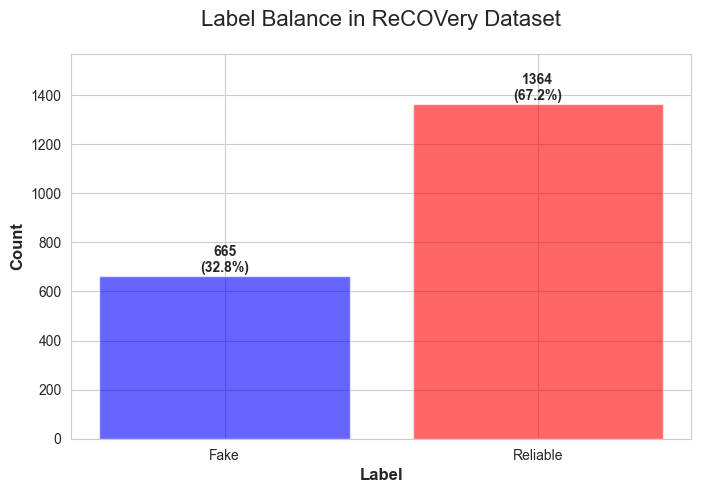

In [4]:
plot_label_distribution(df, dataset_name=dataset_name)

Dataset is quite unbalanced

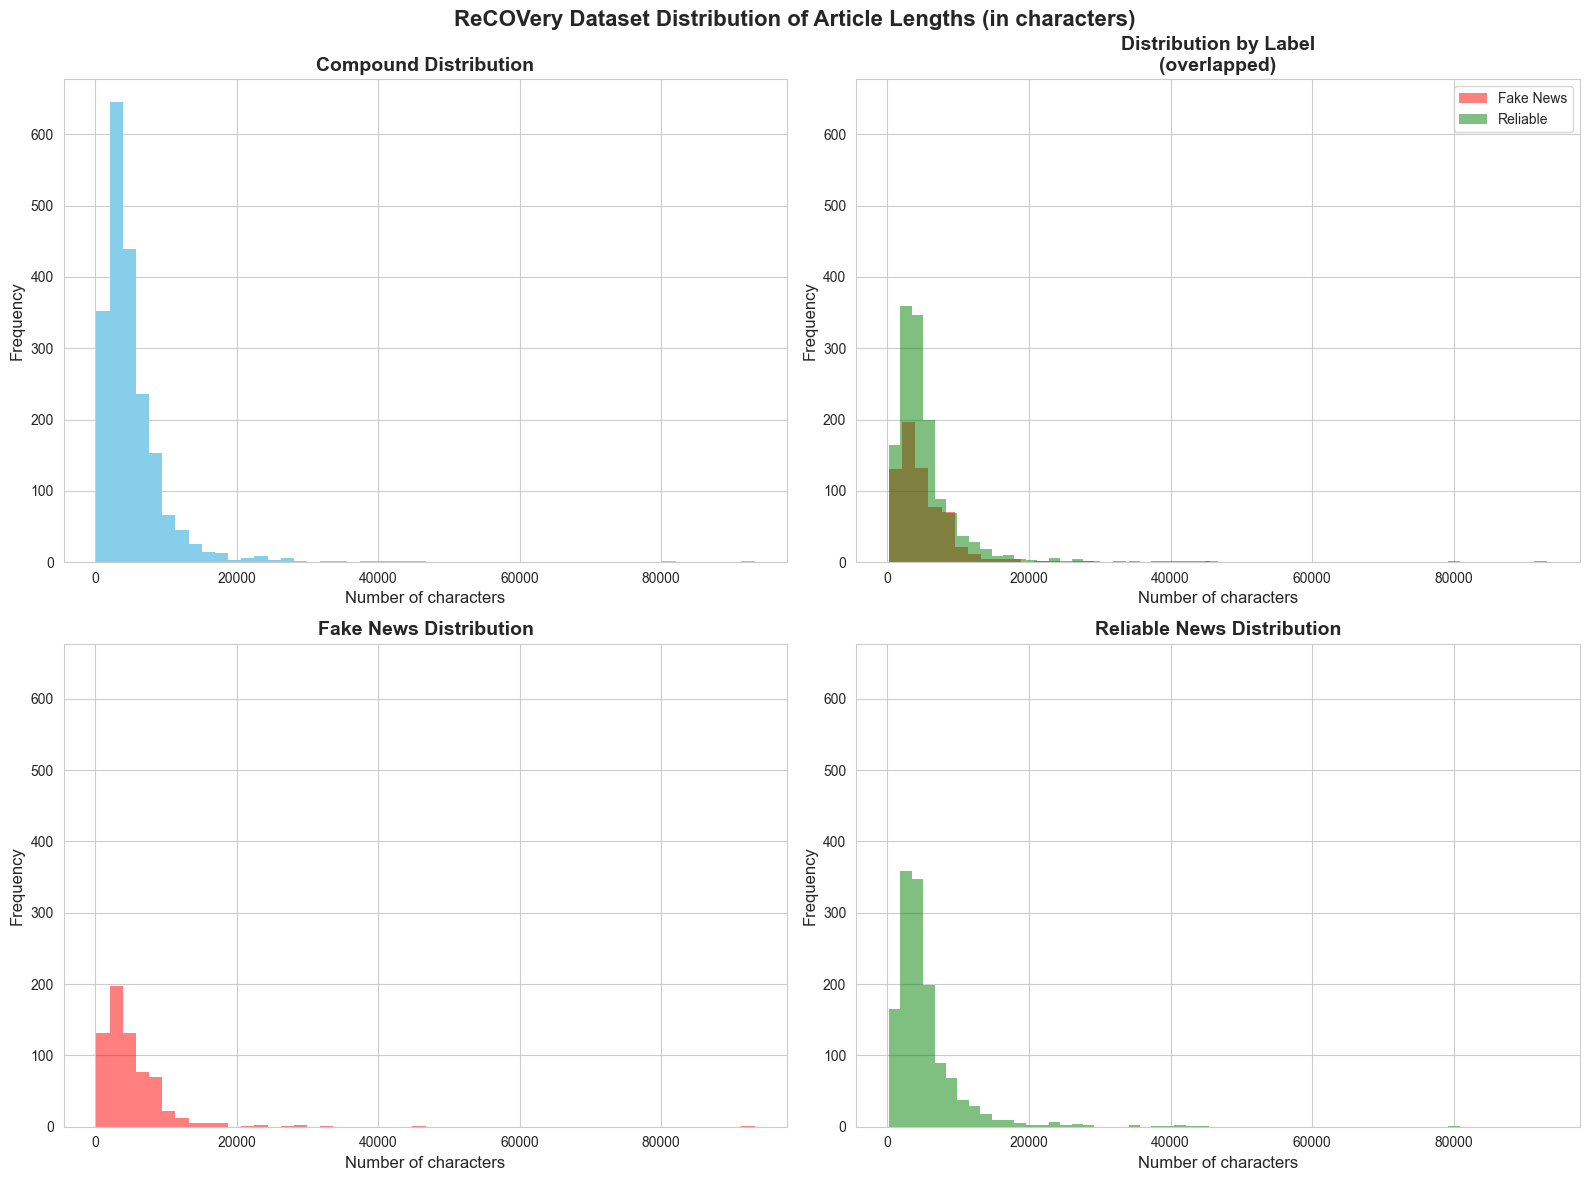

In [5]:
plot_article_length_distribution(df, dataset_name)

### Tokens Analysis

In [6]:
dataset = Dataset(dataset_name,
                  data_path=dataset_path).init(random_state=rd_seed)

2025-05-16 14:08:54,677 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_name': 'recovery', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:08:54,679 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_signature': 'dataset(dn=recovery,tp=0.7,vp=0.15);pipeline([])'}
2025-05-16 14:08:54,680 - Dataset - INFO - {'dataset_name': 'recovery', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:08:54,681 - Dataset - INFO - mlflow is not active, could not log the params: {'preprocessing_pipeline_name': 'empty', 'preprocessing_pipeline_representation': "<PreprocessingPipeline 'empty': []>", 'preprocessing_pipeline': []}
2025-05-16 14:08:54,682 - Dataset - INFO - Prepared dataset does not exist, computing from scratch.
2025-05-16 14:08:54,968 - Dataset - INFO - Initializing preprocessing pipeline: <PreprocessingPipeline 'empty': []>
2025-05-16 14:08:54,970 - Dataset - INFO - artifacts path is none, skipping saving.


In [7]:
train_set_data = dataset.train_set
train_set_data.dataset.head()

,article,label
1132,Messi: Quique Setien Misunderstood My Remark A...,0
832,We hear the cry in nursing homes — ‘Help me!’ ...,1
1198,"The UK is set to have at least 95,000 tonnes o...",1
575,Why are hundreds of people in big cities recei...,1
557,Chicago area companies getting COVID-19 loans ...,1


#### NLTK tokenizer

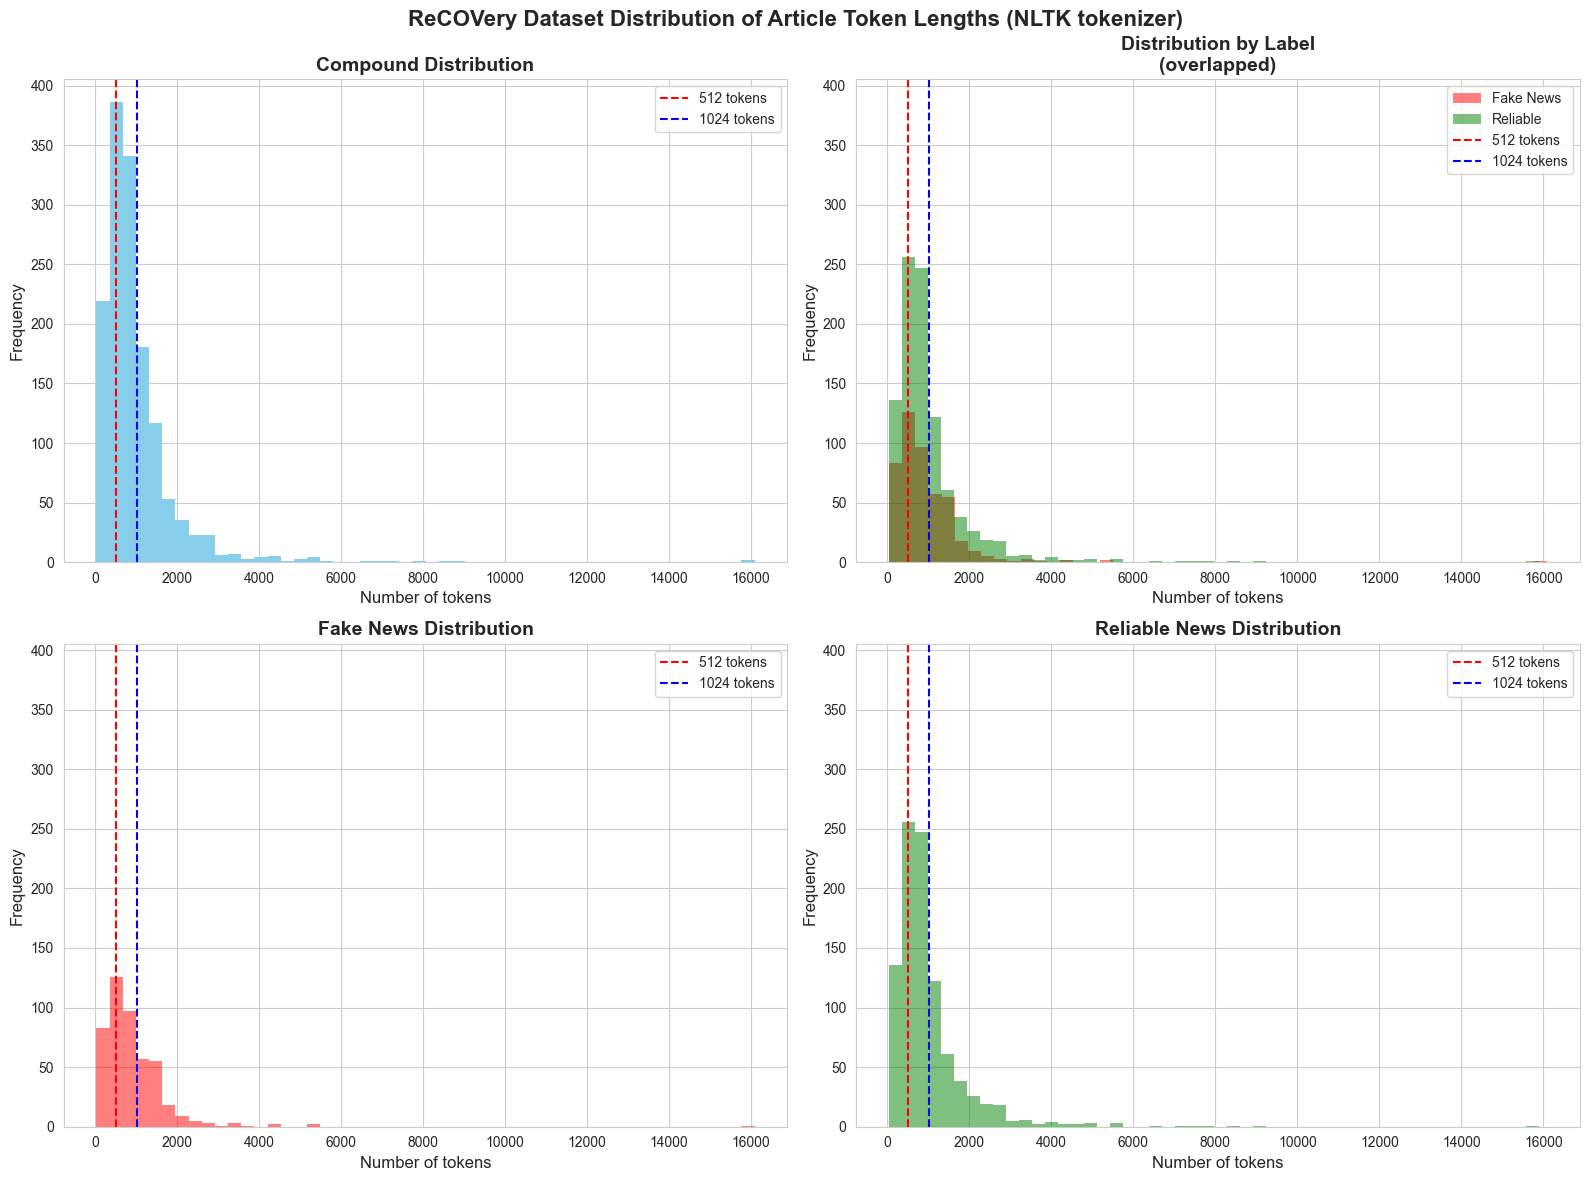

In [8]:
tokenizer = NLTKTokenizer()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='NLTK')

#### BERT Tokenizer

Token indices sequence length is longer than the specified maximum sequence length for this model (861 > 512). Running this sequence through the model will result in indexing errors


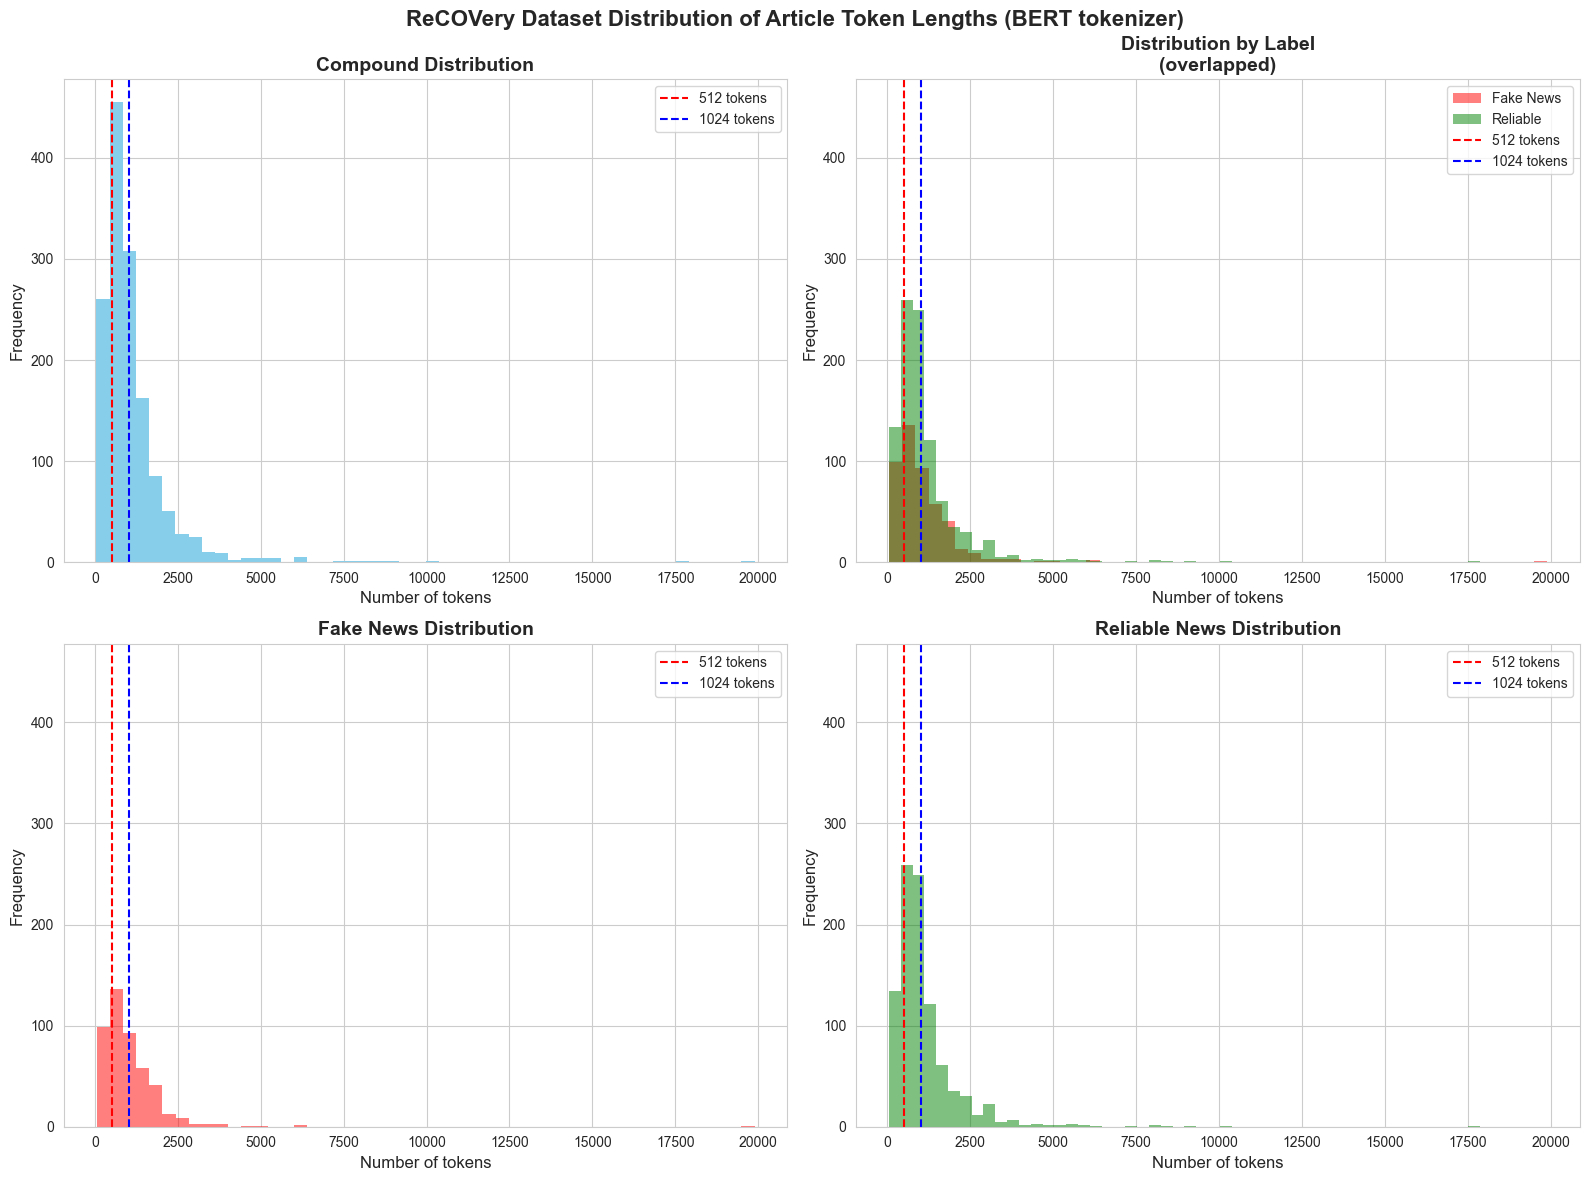

In [9]:
tokenizer = BERTTokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='BERT')

#### GPT1 Tokenizer

Token indices sequence length is longer than the specified maximum sequence length for this model (835 > 512). Running this sequence through the model will result in indexing errors


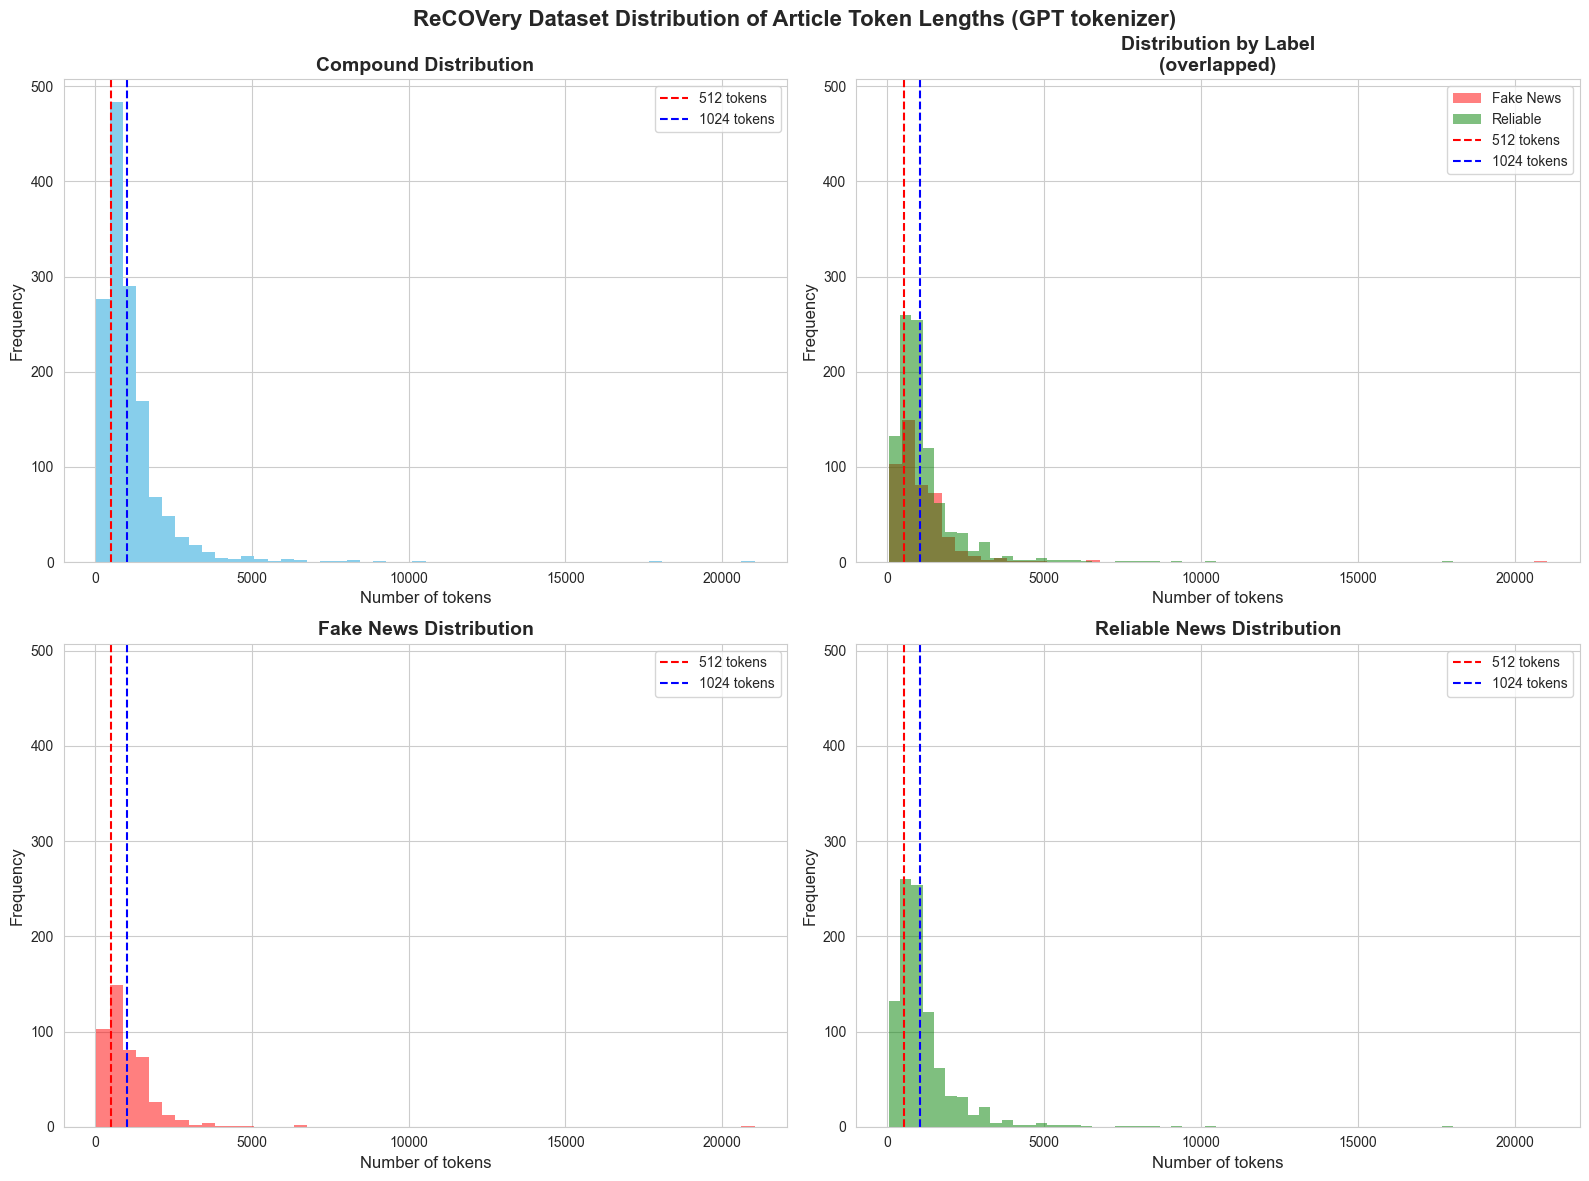

In [10]:
tokenizer = GPT1_Tokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='GPT')